## Uber_Pandas_Queries_Insights_and_Visualisations

# Importing Necessary Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reading and opening of file

In [7]:
file_path = r"C:\Users\91860\Downloads\Uber_Dataset.xlsx"
sheets = pd.read_excel(file_path, sheet_name = None )
sheets.keys()

dict_keys(['drivers', 'vehicles', 'cities', 'riders', 'trips', 'ratings', 'driver_earnings', 'promotions', 'rider_promotions'])

## Question 1: Which city generated the most revenue?

### Join Necessary Tables

In [8]:
trips = sheets['trips']
cities = sheets['cities']

trip_city_merge = trips.merge(
    cities,
    on ='city_id',
    how ='inner'
)

trip_city_merge.head()

,trip_id,rider_id,driver_id,vehicle_id,pickup_location,dropoff_location,pickup_datetime,dropoff_datetime,distance_miles,duration_minutes,fare_amount,surge_multiplier,trip_status,payment_method,city_id,city_name,state,country,timezone,active
0,1001,101,1,1,Market St,Mission District,2024-01-15 08:30:00,2024-01-15 08:50:00,5.2,20,18.5,1.0,completed,credit_card,1,San Francisco,California,USA,PST,1
1,1002,102,2,2,Financial District,SFO Airport,2024-01-15 09:00:00,2024-01-15 09:35:00,14.8,35,45.0,1.5,completed,credit_card,1,San Francisco,California,USA,PST,1
2,1003,103,3,3,Times Square,Brooklyn,2024-01-15 10:15:00,2024-01-15 10:45:00,8.5,30,28.0,1.0,completed,cash,2,New York,New York,USA,EST,1
3,1004,104,4,4,Manhattan,JFK Airport,2024-01-15 11:00:00,2024-01-15 11:50:00,18.2,50,55.0,1.2,completed,credit_card,2,New York,New York,USA,EST,1
4,1005,105,5,5,Hollywood,Santa Monica,2024-01-15 12:30:00,2024-01-15 13:00:00,12.3,30,35.0,1.0,completed,credit_card,3,Los Angeles,California,USA,PST,1


### Summarize Revenue by City

In [11]:
city_revenue = (
    trip_city_merge
    .groupby('city_name', as_index = False)['fare_amount']
    .sum()
    .sort_values(by = 'fare_amount', ascending = False)
)
city_revenue

,city_name,fare_amount
2,San Francisco,85.5
1,New York,83.0
0,Los Angeles,35.0


### Visualization 1: Revenue by City

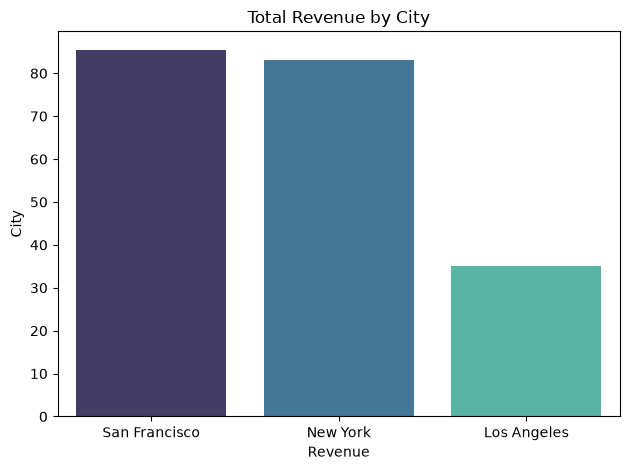

In [12]:
plt.Figure(figsize=(10,6))
sns.barplot(
            data = city_revenue, x = 'city_name', y = 'fare_amount',
            hue = 'city_name',
            palette = 'mako',
            legend = False
)

plt.title('Total Revenue by City')
plt.xlabel('Revenue')
plt.ylabel('City')
plt.tight_layout()
plt.show()

### Insight
San Francisco generated the highest total revenue in this dataset, followed closely by New York.

## Question 2: Which vehicle type was used the most?

### Join Necessary Tables

In [14]:
vehicles = sheets["vehicles"]

trip_vehicle_data = trips.merge(
    vehicles,
    on="vehicle_id",
    how="inner"
)

trip_vehicle_data.head()

,trip_id,rider_id,driver_id,vehicle_id,pickup_location,dropoff_location,pickup_datetime,dropoff_datetime,distance_miles,duration_minutes,...,trip_status,payment_method,city_id,make,model,year,color,license_plate,vehicle_type,status
0,1001,101,1,1,Market St,Mission District,2024-01-15 08:30:00,2024-01-15 08:50:00,5.2,20,...,completed,credit_card,1,Toyota,Camry,2022,Silver,ABC123,UberX,active
1,1002,102,2,2,Financial District,SFO Airport,2024-01-15 09:00:00,2024-01-15 09:35:00,14.8,35,...,completed,credit_card,1,Honda,Accord,2023,Black,XYZ789,UberX,active
2,1003,103,3,3,Times Square,Brooklyn,2024-01-15 10:15:00,2024-01-15 10:45:00,8.5,30,...,completed,cash,2,Tesla,Model 3,2023,White,TES456,UberBlack,active
3,1004,104,4,4,Manhattan,JFK Airport,2024-01-15 11:00:00,2024-01-15 11:50:00,18.2,50,...,completed,credit_card,2,Chevrolet,Suburban,2022,Blue,SUV999,UberXL,active
4,1005,105,5,5,Hollywood,Santa Monica,2024-01-15 12:30:00,2024-01-15 13:00:00,12.3,30,...,completed,credit_card,3,Ford,Fusion,2021,Red,FOR321,UberX,active


### Summarize Trips by Vehicle Type

In [15]:
vehicle_trips = (
    trip_vehicle_data
    .groupby("vehicle_type", as_index=False)["trip_id"]
    .count()
    .rename(columns={"trip_id": "total_trips"})
    .sort_values("total_trips", ascending=False)
)

vehicle_trips

,vehicle_type,total_trips
1,UberX,4
0,UberBlack,1
2,UberXL,1


### Visualization 2: Trips by Vehicle Type

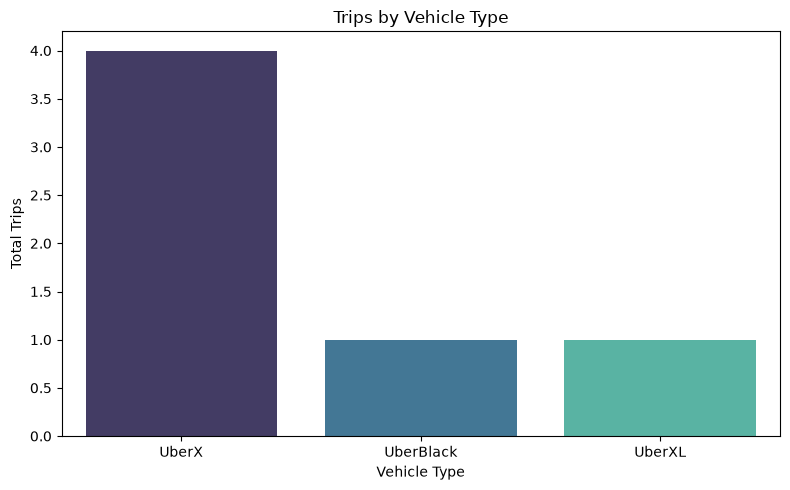

In [16]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=vehicle_trips,
    x="vehicle_type",
    y="total_trips",
    hue="vehicle_type",
    palette="mako",
    legend=False
)

plt.title("Trips by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Total Trips")
plt.tight_layout()
plt.show()

### Insight
UberX was used the most, showing that standard ride options had the highest demand in this dataset.

## Question 3: Which payment method was used the most?

### Summarize Trips by Payment Method

In [17]:
payment_methods = (
    trips
    .groupby("payment_method", as_index=False)["trip_id"]
    .count()
    .rename(columns={"trip_id": "total_trips"})
    .sort_values("total_trips", ascending=False)
)

payment_methods

,payment_method,total_trips
1,credit_card,5
0,cash,1


### Visualization 3: Trips by Payment Method

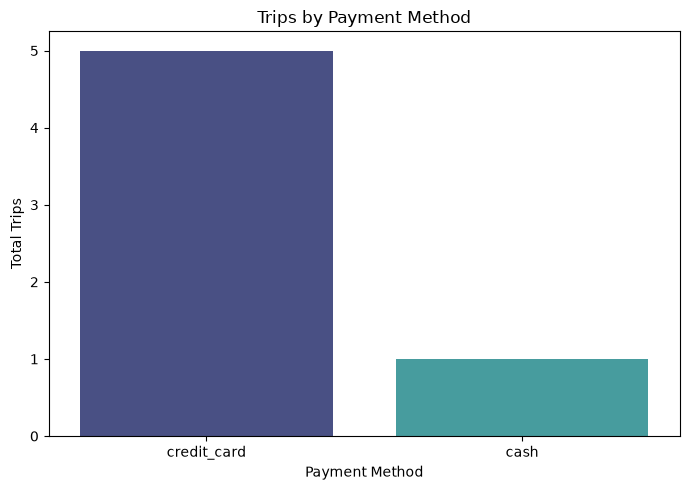

In [18]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=payment_methods,
    x="payment_method",
    y="total_trips",
    hue="payment_method",
    palette="mako",
    legend=False
)

plt.title("Trips by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Trips")
plt.tight_layout()
plt.show()

### Insight
Credit card was the most used payment method, indicating that most completed trips were paid digitally.

## Question 4: How much revenue came from promoted vs non-promoted trips?

### Join Necessary Tables

In [19]:
rider_promotions = sheets["rider_promotions"]

promo_data = trips.merge(
    rider_promotions[["trip_id", "discount_applied"]],
    on="trip_id",
    how="left"
)

promo_data["promotion_status"] = promo_data["discount_applied"].notna().map({
    True: "Promoted",
    False: "Non-Promoted"
})

promo_data.head()

,trip_id,rider_id,driver_id,vehicle_id,pickup_location,dropoff_location,pickup_datetime,dropoff_datetime,distance_miles,duration_minutes,fare_amount,surge_multiplier,trip_status,payment_method,city_id,discount_applied,promotion_status
0,1001,101,1,1,Market St,Mission District,2024-01-15 08:30:00,2024-01-15 08:50:00,5.2,20,18.5,1.0,completed,credit_card,1,1.85,Promoted
1,1002,102,2,2,Financial District,SFO Airport,2024-01-15 09:00:00,2024-01-15 09:35:00,14.8,35,45.0,1.5,completed,credit_card,1,5.00,Promoted
2,1003,103,3,3,Times Square,Brooklyn,2024-01-15 10:15:00,2024-01-15 10:45:00,8.5,30,28.0,1.0,completed,cash,2,NaN,Non-Promoted
3,1004,104,4,4,Manhattan,JFK Airport,2024-01-15 11:00:00,2024-01-15 11:50:00,18.2,50,55.0,1.2,completed,credit_card,2,NaN,Non-Promoted
4,1005,105,5,5,Hollywood,Santa Monica,2024-01-15 12:30:00,2024-01-15 13:00:00,12.3,30,35.0,1.0,completed,credit_card,3,7.00,Promoted


### Summarize Revenue by Promotion Status

In [20]:
promo_revenue = (
    promo_data
    .groupby("promotion_status", as_index=False)["fare_amount"]
    .sum()
    .sort_values("fare_amount", ascending=False)
)

promo_revenue

,promotion_status,fare_amount
0,Non-Promoted,105.0
1,Promoted,98.5


### Visualization 4: Revenue by Promotion Status

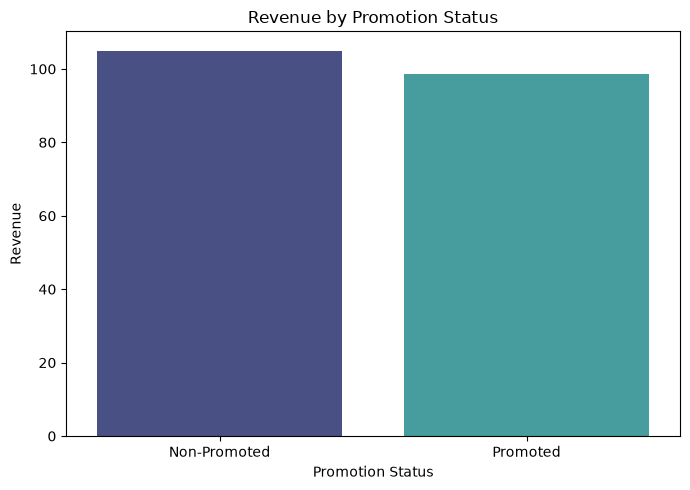

In [21]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=promo_revenue,
    x="promotion_status",
    y="fare_amount",
    hue="promotion_status",
    palette="mako",
    legend=False
)

plt.title("Revenue by Promotion Status")
plt.xlabel("Promotion Status")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

### Insight
Non-promoted trips generated slightly more total revenue than promoted trips, though both groups had the same number of trips.